# 01_load_check

東京電力PowerGrid「でんき予報」過去実績CSV (2021〜2025) の読み込み確認。


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Meiryo"

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
IMG_DIR = PROJECT_ROOT / "docs" / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR)
print("IMG_DIR:", IMG_DIR)

RAW_DIR: c:\Users\koudai.sugawara\power-demand-analysis\data\raw
IMG_DIR: c:\Users\koudai.sugawara\power-demand-analysis\docs\images


In [2]:
df_2024 = pd.read_csv(RAW_DIR / "juyo-2024.csv", encoding="shift_jis", skiprows=2)

print("shape:", df_2024.shape)
print("columns:", list(df_2024.columns))
df_2024.head()

shape: (8784, 3)
columns: ['DATE', 'TIME', '実績(万kW)']


,DATE,TIME,実績(万kW)
0,2024/1/1,0:00,2402
1,2024/1/1,1:00,2286
2,2024/1/1,2:00,2243
3,2024/1/1,3:00,2229
4,2024/1/1,4:00,2229


In [3]:
df_2024.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   DATE     8784 non-null   str  
 1   TIME     8784 non-null   str  
 2   実績(万kW)  8784 non-null   int64
dtypes: int64(1), str(2)
memory usage: 206.0 KB


## 5年分をまとめて読み込み

各年のCSVを読み込み、datetime列を作って縦に連結する。


In [4]:
def load_year(year):
    path = RAW_DIR / f"juyo-{year}.csv"
    df = pd.read_csv(path, encoding="shift_jis", skiprows=2)
    df = df.rename(columns={"実績(万kW)": "demand"})

    df["datetime"] = pd.to_datetime(
        df["DATE"] + " " + df["TIME"], format="%Y/%m/%d %H:%M"
    )

    df["year"] = year
    return df[["datetime", "year", "demand"]]


years = [2021, 2022, 2023, 2024, 2025]
df_all = pd.concat([load_year(y) for y in years], ignore_index=True)

print("total_shape:", df_all.shape)
df_all.head()

total_shape: (39912, 3)


,datetime,year,demand
0,2021-01-01 00:00:00,2021,3184
1,2021-01-01 01:00:00,2021,2978
2,2021-01-01 02:00:00,2021,2834
3,2021-01-01 03:00:00,2021,2743
4,2021-01-01 04:00:00,2021,2697


## 年ごとのサマリ

行数・欠損・期間を年単位で集計して、データの揃い具合を確認する。


In [5]:
summary = (
    df_all.groupby("year")
    .agg(
        rows=("demand", "size"),
        n_missing=("demand", lambda s: s.isna().sum()),
        start=("datetime", "min"),
        end=("datetime", "max"),
    )
    .reset_index()
)
summary

,year,rows,n_missing,start,end
0,2021,8760,0,2021-01-01,2021-12-31 23:00:00
1,2022,8760,0,2022-01-01,2022-12-31 23:00:00
2,2023,8760,0,2023-01-01,2023-12-31 23:00:00
3,2024,8784,0,2024-01-01,2024-12-31 23:00:00
4,2025,4848,0,2025-01-01,2025-07-21 23:00:00


## 全期間の時系列折れ線

2021年〜2025年7月の電力需要（万kW）を1本の折れ線で表示。

<function matplotlib.pyplot.show(close=None, block=None)>

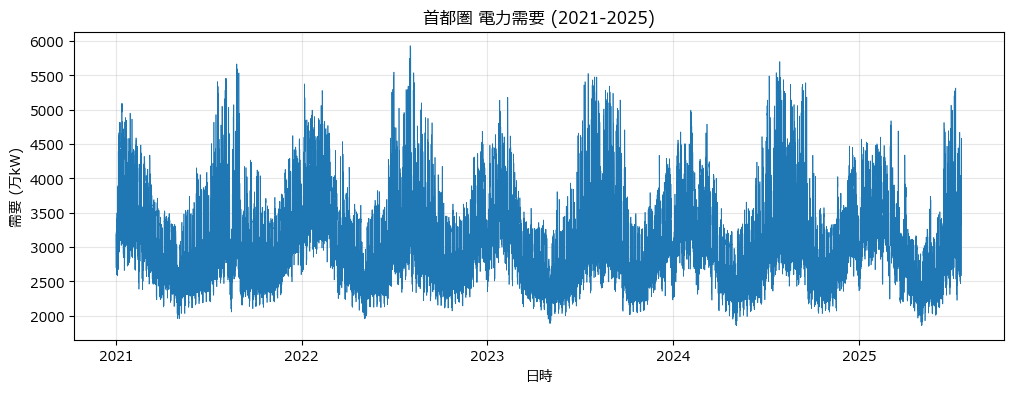

In [6]:
plt.rcParams["font.family"] = "Meiryo"

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_all["datetime"], df_all["demand"], linewidth=0.5)

ax.set_title("首都圏 電力需要 (2021-2025)")
ax.set_xlabel("日時")
ax.set_ylabel("需要 (万kW)")
ax.grid(True, alpha=0.3)

fig.savefig(IMG_DIR / "01_full_timeseries.png", dpi=120, bbox_inches="tight")
plt.show

## 年次比較：1月1日からの経過日で重ねる



df_daily shape: (1663, 4)


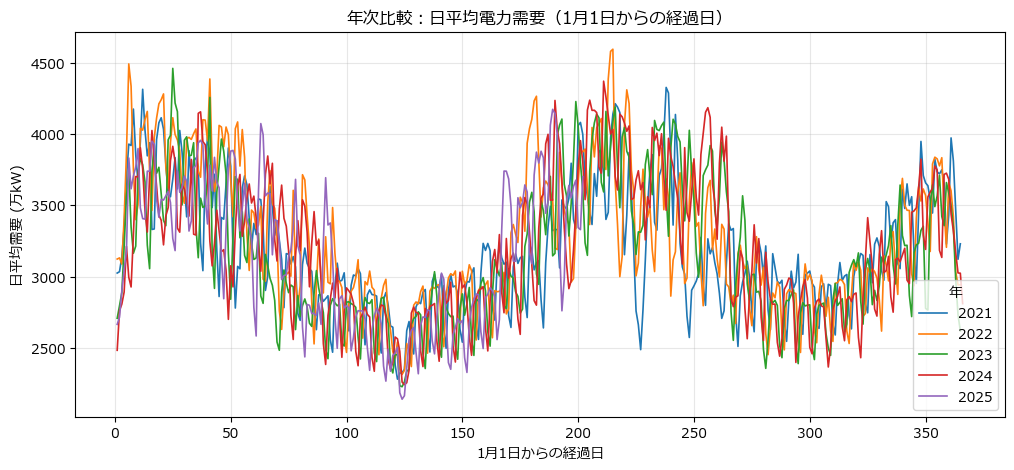

In [7]:
df_daily = df_all.set_index("datetime").resample("D")["demand"].mean().reset_index()

df_daily["year"] = df_daily["datetime"].dt.year
df_daily["dayofyear"] = df_daily["datetime"].dt.dayofyear

print("df_daily shape:", df_daily.shape)
df_daily.head()

fig, ax = plt.subplots(figsize=(12, 5))

for year in [2021, 2022, 2023, 2024, 2025]:
    sub = df_daily[df_daily["year"] == year]
    ax.plot(sub["dayofyear"], sub["demand"], label=str(year), linewidth=1.2)


ax.set_title("年次比較：日平均電力需要（1月1日からの経過日）")
ax.set_xlabel("1月1日からの経過日")
ax.set_ylabel("日平均需要 (万kW)")
ax.legend(title="年")
ax.grid(True, alpha=0.3)

fig.savefig(IMG_DIR / "02_yearly_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

## 月平均ヒートマップ（年×月）


In [8]:
df_all["year"] = df_all["datetime"].dt.year
df_all["month"] = df_all["datetime"].dt.month

heatmap_data = df_all.pivot_table(
    index="year",
    columns="month",
    values="demand",
    aggfunc="mean",
)

print("heatmap_data:")
heatmap_data

heatmap_data:


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2021,3732.815860,3498.648810,3112.064516,2823.631944,2707.439516,3006.069444,3471.223118,3604.869624,2995.844444,2914.094086,3003.190278,3497.452957
2022,3831.580645,3848.924107,3168.158602,2874.086111,2736.391129,3142.129167,3643.090054,3594.970430,3216.923611,2828.884409,2902.309722,3412.071237
2023,3589.923387,3495.915179,2880.314516,2685.366667,2617.439516,2950.033333,3655.196237,3774.674731,3468.252778,2731.400538,2898.148611,3247.268817
2024,3429.891129,3441.629310,3251.758065,2688.861111,2664.467742,2964.391667,3758.883065,3772.405914,3461.973611,2829.354839,2861.652778,3329.971774
2025,3499.118280,3575.657738,3138.178763,2729.879167,2576.436828,3104.186111,3622.456349,NaN,NaN,NaN,NaN,NaN


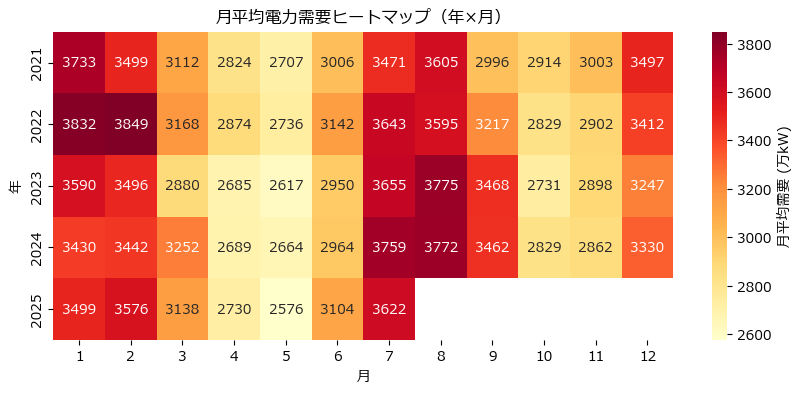

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={"label": "月平均需要 (万kW)"},
    ax=ax,
)

ax.set_title("月平均電力需要ヒートマップ（年×月）")
ax.set_xlabel("月")
ax.set_ylabel("年")

fig.savefig(IMG_DIR / "03_year_month_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 時間帯×曜日ヒートマップ

In [10]:
df_all["hour"] = df_all["datetime"].dt.hour
df_all["dayofweek"] = df_all["datetime"].dt.dayofweek

heatmap_data_dow = df_all.pivot_table(
    index="hour", columns="dayofweek", values="demand", aggfunc="mean"
)

dow_jp = ["月", "火", "水", "木", "金", "土", "日"]
heatmap_data_dow.columns = dow_jp

print("shape:", heatmap_data_dow.shape)


heatmap_data_dow.head()

shape: (24, 7)


,月,火,水,木,金,土,日
hour,,,,,,,
0,2529.105042,2718.962025,2738.573840,2723.194093,2722.235294,2717.491597,2565.600840
1,2414.760504,2587.426160,2604.493671,2591.139241,2590.571429,2580.500000,2443.810924
2,2389.810924,2552.219409,2567.379747,2555.362869,2554.407563,2533.626050,2406.273109
3,2410.638655,2562.721519,2575.417722,2565.582278,2565.067227,2531.243697,2409.180672
4,2451.521008,2594.113924,2604.379747,2595.329114,2595.546218,2532.478992,2413.037815


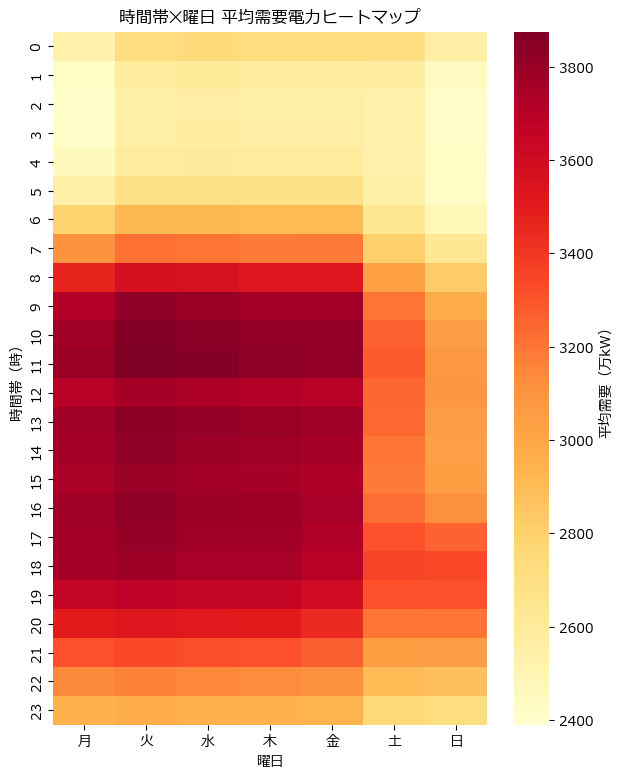

In [11]:
fig, ax = plt.subplots(figsize=(7, 9))

sns.heatmap(
    heatmap_data_dow, cmap="YlOrRd", cbar_kws={"label": "平均需要（万kW）"}, ax=ax
)

ax.set_title("時間帯✕曜日 平均需要電力ヒートマップ")
ax.set_xlabel("曜日")
ax.set_ylabel("時間帯（時）")

fig.savefig(IMG_DIR / "04_hour_dow_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## ピーク日の24時間負荷曲線（夏 vs 冬）

夏ピーク:2022-08-02 13:00:00 → 5,930万kW
冬ピーク:2022-01-06 16:00:00 → 5,374万kW


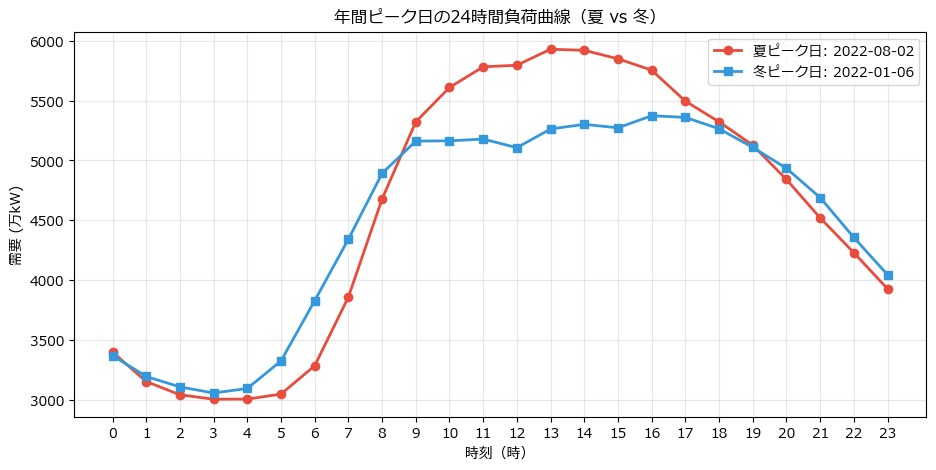

In [12]:
summer_months = [6, 7, 8, 9]
winter_months = [12, 1, 2]

summer_peak_idx = df_all[df_all["month"].isin(summer_months)]["demand"].idxmax()
winter_peak_idx = df_all[df_all["month"].isin(winter_months)]["demand"].idxmax()

summer_peak_row = df_all.loc[summer_peak_idx]
winter_peak_row = df_all.loc[winter_peak_idx]

print(f"夏ピーク:{summer_peak_row['datetime']} → {summer_peak_row['demand']:,}万kW")
print(f"冬ピーク:{winter_peak_row['datetime']} → {winter_peak_row['demand']:,}万kW")

fig, ax = plt.subplots(figsize=(11, 5))

summer_date = summer_peak_row["datetime"].date()
winter_date = winter_peak_row["datetime"].date()

summer_curve = df_all[df_all["datetime"].dt.date == summer_date]
winter_curve = df_all[df_all["datetime"].dt.date == winter_date]


ax.plot(
    summer_curve["datetime"].dt.hour,
    summer_curve["demand"],
    label=f"夏ピーク日: {summer_date}",
    color="#E74C3C",
    marker="o",
    linewidth="2",
)

ax.plot(
    winter_curve["datetime"].dt.hour,
    winter_curve["demand"],
    label=f"冬ピーク日: {winter_date}",
    color="#3498DB",
    marker="s",
    linewidth="2",
)

ax.set_title("年間ピーク日の24時間負荷曲線（夏 vs 冬）")
ax.set_xlabel("時刻（時）")
ax.set_ylabel("需要 (万kW)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(IMG_DIR / "05_peak_day_curve.png", dpi=120, bbox_inches="tight")
plt.show()

In [13]:
print(f"画像保存先: {IMG_DIR}")

画像保存先: c:\Users\koudai.sugawara\power-demand-analysis\docs\images
